## Practical case 2
Sofía Jimeno Lucía

In [1]:
# Libraries
import cv2
import os
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Ellipse
import numpy as np
from skimage.feature import canny
from skimage.transform import probabilistic_hough_line, hough_circle, hough_circle_peaks
import pygame as pg
from pygame.math import Vector2
import math
import pandas as pd

pygame 2.1.2 (SDL 2.0.18, Python 3.7.6)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [2]:
# Functions
%run .\main.py

In [3]:
# Variables
path ='./DataSet/'
list_img = os.listdir(path)

### Identification of aortic parameters

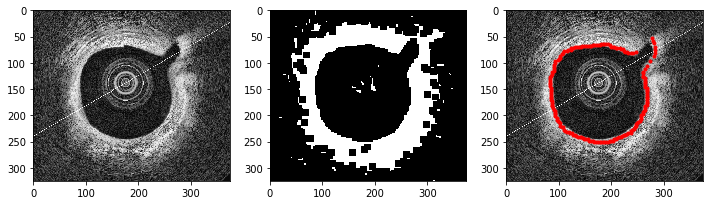

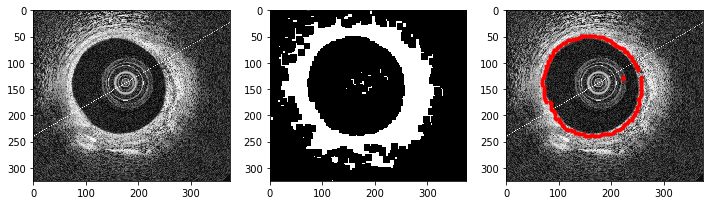

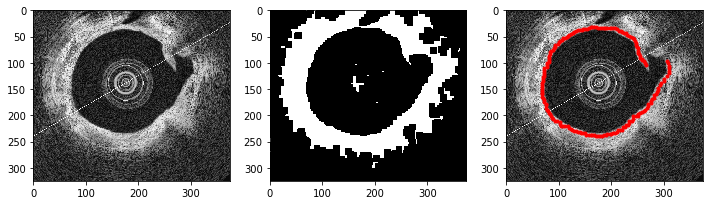

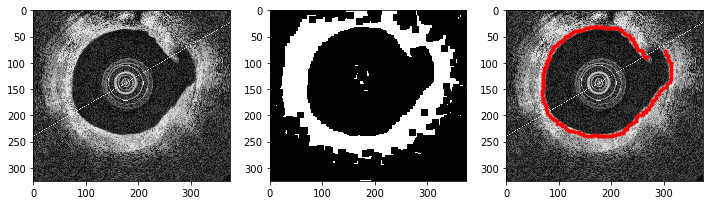

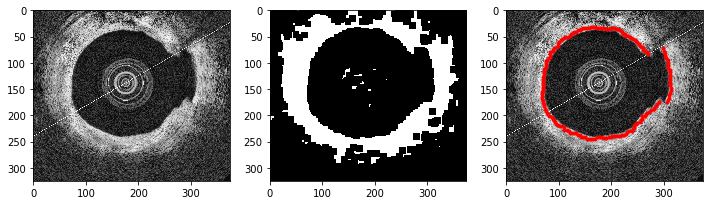

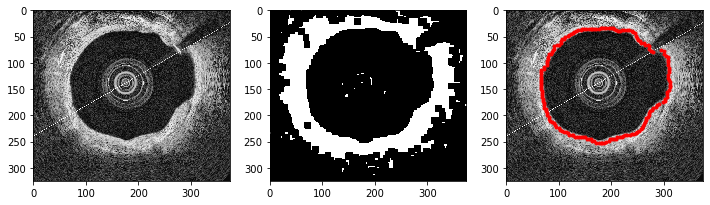

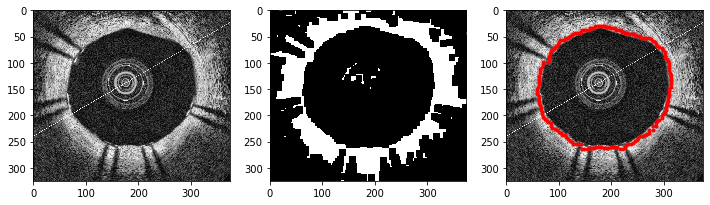

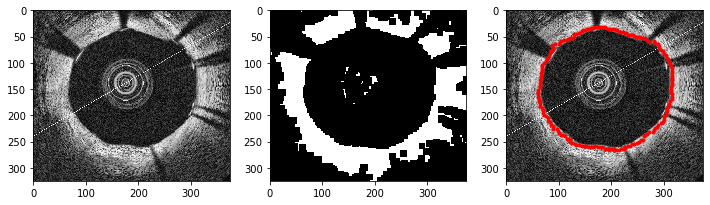

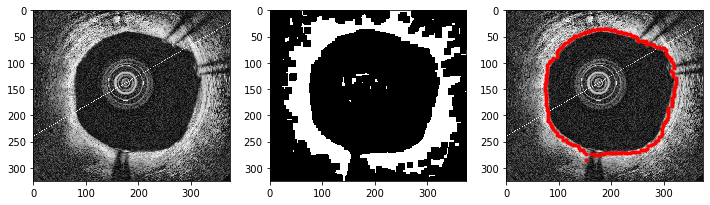

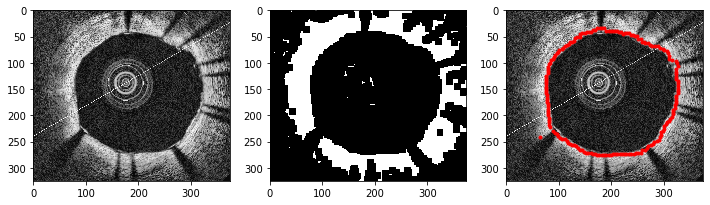

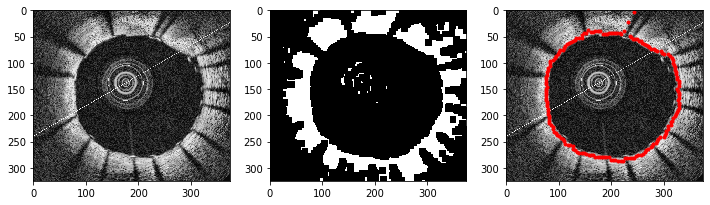

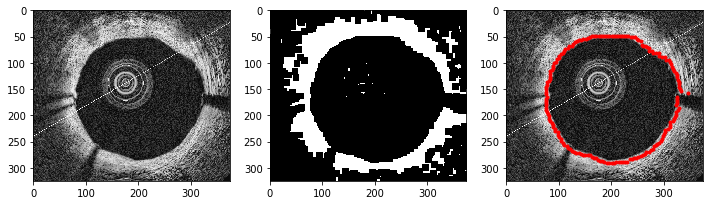

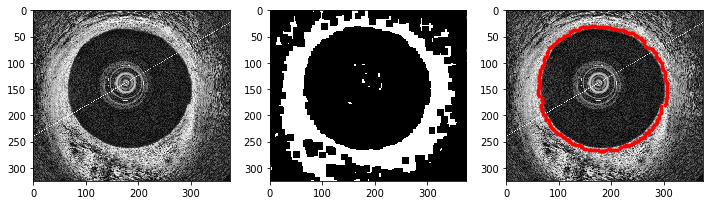

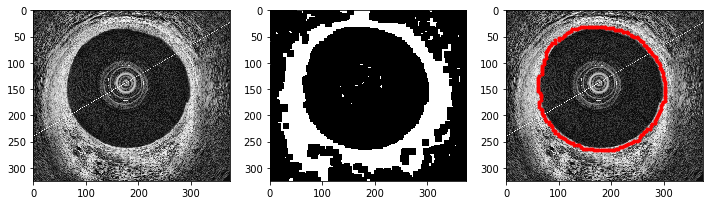

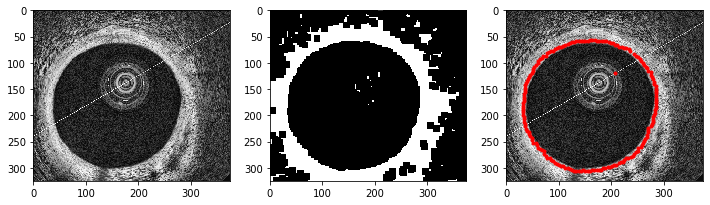

In [4]:
list_radius = []
list_area = []
list_appareance = []
list_grade_cir = []

for img in list_img:
    
    # Cropping and gray color
    im = cv2.imread(path + img)[125:450, 175:550, ::-1]
    gray = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)

    # Histogram equalization
    clahe = cv2.createCLAHE(clipLimit = 10.0, tileGridSize = (8, 8))
    cl1 = clahe.apply(gray)
    
    # Binarization
    _ , mask = cv2.threshold(cl1, 11, 255, cv2.THRESH_BINARY)
    
    # Erosion operation
    mask = cv2.erode(mask, np.ones((13, 13), np.uint8))
    
    # Extracting edges
    edge = np.uint8(canny(mask, sigma = 3))

    # Getting circles within the image
    radius = np.arange(50, 150)
    h = hough_circle(edge, radius = radius)
    accum, cx, cy, rad = hough_circle_peaks(h, radii = radius, min_xdistance = 50, min_ydistance = 50, threshold = 0.2)

    # Estimating distances of the walls
    if len(rad)==0:
        h = hough_circle(mask, radius = radius)
        accum, cx, cy, rad = hough_circle_peaks(h, radii = radius, min_xdistance = 50, min_ydistance = 50, threshold = 0.2)
    distances, points, rad_right, rad_left, rad_top, rad_down = estimate_distances(180, (cx[:1], cy[:1]), rad[:1], mask)
    
    # Aortic parameters
    list_area += [math.pi * np.mean(distances)**2]
    list_radius += [np.mean(distances)]
    list_appareance += [np.std(distances)]
    diam1 = rad_right + rad_left
    diam2 = rad_top + rad_down
    list_grade_cir += [diam1/diam2]
    
    # Plotting
    fu, ax = plt.subplots(1, 3, figsize = (12,12))
    ax[0].imshow(cl1, cmap = 'gray')
    ax[1].imshow(mask, cmap = 'gray')
    for x, y in points:
        plt.plot(x, y, marker = '.', color = "red")
    ax[2].imshow(cl1,cmap='gray')
    plt.show()
    

In [5]:
# Table with the results
list_appareance_cat = ['irregular' if sd > 5.5 else 'non-irregular' for sd in list_appareance]
pd.DataFrame(list(zip(list_img, list_radius, list_area, list_appareance, list_appareance_cat, list_grade_cir)), columns = ['file','radius','area','appearence','appearence cat','degree_circularity'])

,file,radius,area,appearence,appearence cat,degree_circularity
0,m001-IMG002-00038.png,95.800000,28832.406401,9.035977,irregular,0.989189
1,m001-IMG002-00042.png,93.516667,27474.380546,5.165564,non-irregular,0.973684
2,m001-IMG002-00074.png,105.772222,35147.394032,8.556239,irregular,1.111111
3,m001-IMG002-00075.png,108.755556,37158.038055,9.978099,irregular,1.164251
4,m001-IMG002-00076.png,111.522222,39072.635156,10.077177,irregular,1.153110
5,m001-IMG002-00077.png,114.277778,41027.348068,7.816688,irregular,1.118721
6,m001-IMG002-00082.png,121.155556,46114.397570,9.485558,irregular,1.081897
7,m001-IMG002-00083.png,121.522222,46393.942302,9.794247,irregular,1.086580
8,m001-IMG002-00088.png,123.300000,47761.287537,5.096731,non-irregular,1.047009
9,m001-IMG002-00089.png,124.288889,48530.468489,6.642865,irregular,1.067511


### Struts' identification

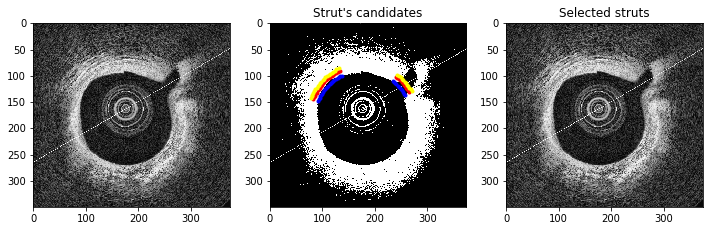

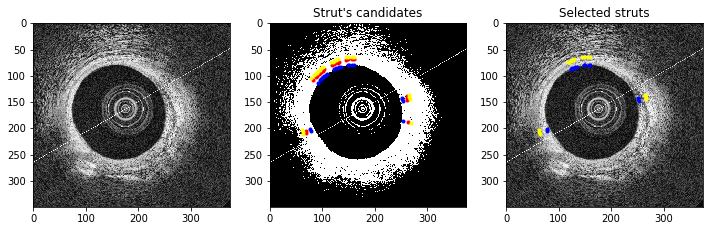

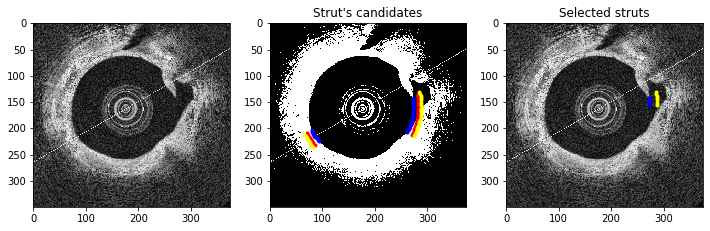

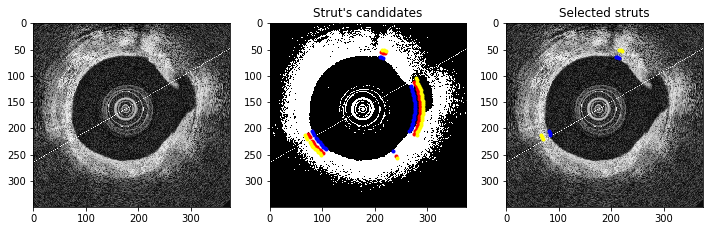

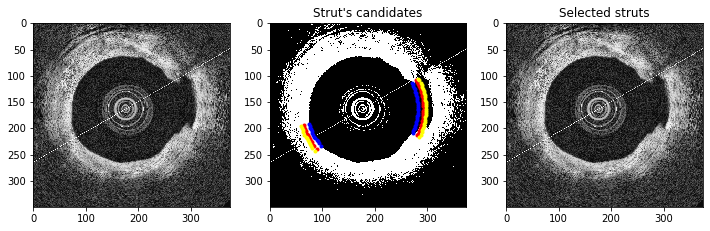

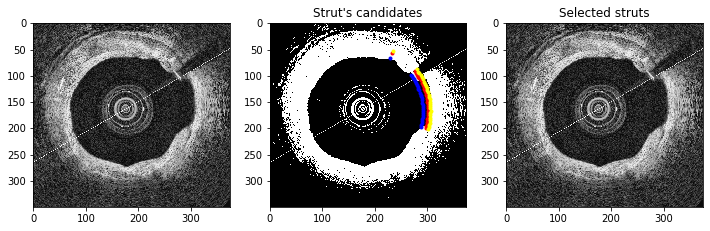

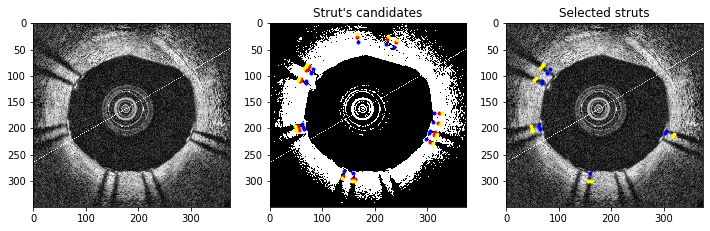

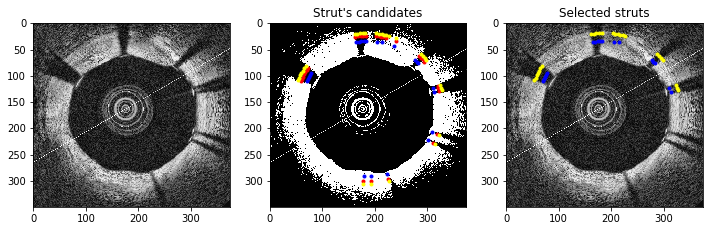

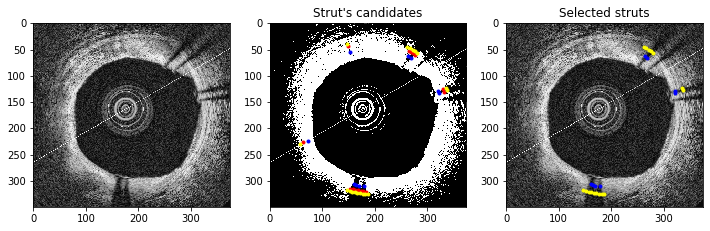

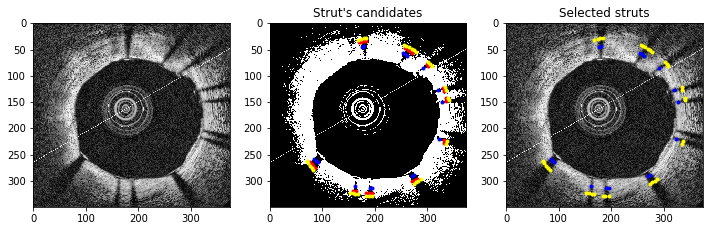

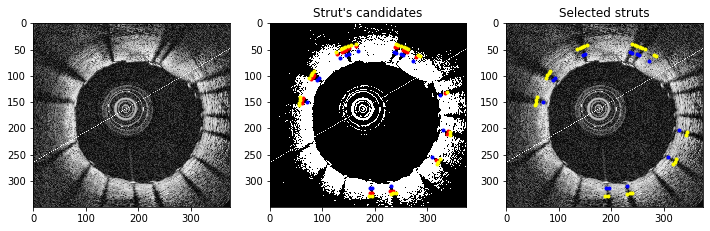

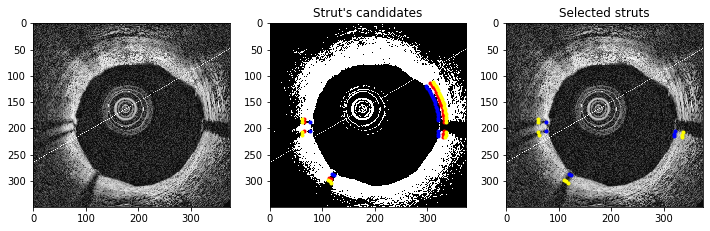

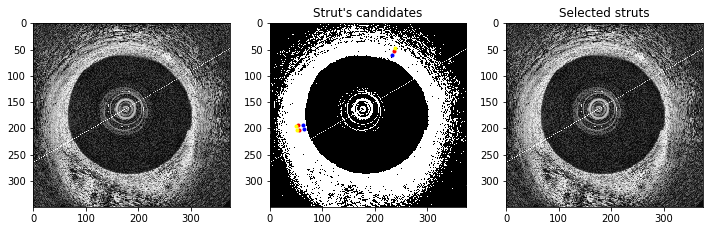

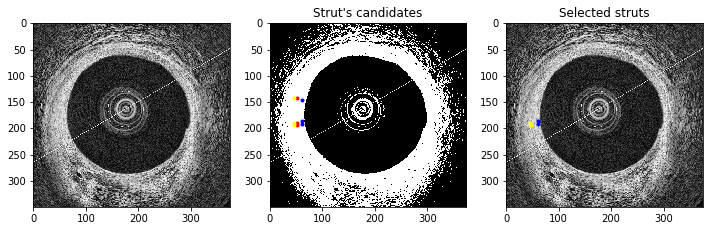

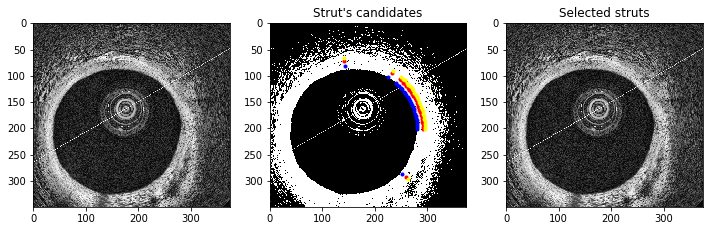

In [7]:
list_strut_cat = []
list_big_strut = []
list_small_strut = []
list_total_strut = []
min_p_candidate = 1
max_p_candidate = 5


for img in list_img:
    
    # Cropping and gray color
    im = cv2.imread(path + img)[100:450, 175:550, ::-1]
    gray = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)

    # Histogram equalization
    clahe = cv2.createCLAHE(clipLimit = 10.0, tileGridSize = (8, 8))
    cl1 = clahe.apply(gray)
    
    # Binarization
    _ , mask = cv2.threshold(cl1, 11, 255, cv2.THRESH_BINARY)
    
    # Erosion operation
    mask = cv2.erode(mask, np.ones((13, 13), np.uint8))
    
    # Extracting edges
    edge = np.uint8(canny(mask, sigma = 3))

    # Getting circles within the image
    radius = np.arange(50, 150)
    h = hough_circle(edge, radius = radius)
    accum, cx, cy, rad = hough_circle_peaks(h, radii = radius, min_xdistance = 50, min_ydistance = 50, threshold = 0.2)

    # Estimating distances of the walls
    if len(rad)==0:
        h = hough_circle(mask, radius = radius)
        accum, cx, cy, rad = hough_circle_peaks(h, radii = radius, min_xdistance = 50, min_ydistance = 50, threshold = 0.2)
    distances, points, rad_right, rad_left, rad_top, rad_down = estimate_distances(180, (cx[:1], cy[:1]), rad[:1], mask)
    

    # Getting different areas for searching candidates
    points_circle_15 = circ_points(180, (cx[:1], cy[:1]), rad[:1]+15)
    points_circle_10 = circ_points(180, (cx[:1], cy[:1]), rad[:1]+10)
    points_circle_5 = circ_points(180, (cx[:1], cy[:1]), rad[:1]+5)
    points_circle = circ_points(180, (cx[:1], cy[:1]), rad[:1])

    _ , binary = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)
    bw_circle_15_points = [(i, 255 if i[1] <= 5 else binary[i[1], i[0]]) for i in points_circle_15]
    bw_circle_10_points = [(i, 255 if i[1] <= 5 else binary[i[1], i[0]]) for i in points_circle_10]
    bw_circle_5_points = [(i, 255 if i[1] <= 5 else binary[i[1], i[0]]) for i in points_circle_5]
    bw_circle_points = [(i, 255 if i[1] <= 5 else binary[i[1], i[0]]) for i in points_circle]
    bw_area_points = [(i, 255 if i[1] <= 5 else binary[i[1], i[0]]) for i in points]


    # Selecting the struts
    selection_1_order,selection_2_order,selection_3_order, pos_struts_1, pos_struts_3 = struts_selection(cl1,bw_area_points,bw_circle_points,bw_circle_5_points,bw_circle_10_points,bw_circle_15_points, min_p_candidate,max_p_candidate)
     
    # Size of each strut found
    unique, counts = np.unique(np.array(list(pos_struts_1.values())), return_counts=True)
    struts_1 = dict(zip(unique, counts))
    
    unique, counts = np.unique(np.array(list(pos_struts_3.values())), return_counts=True)
    struts_3 = dict(zip(unique, counts))
    
    ## Categorization
    big = 0
    small = 0
    struts_cat = {}
    for item, value in list(struts_1.items()):
    #     print(value)
        if value > 4:
            big +=1
            struts_cat[item] = 'big'
        else:
            small += 1
            struts_cat[item] = 'small'
    
    list_small_strut += [small]
    list_big_strut += [big]
    list_strut_cat += [struts_cat]
    list_total_strut += [big+small]
    
    
    # Plotting candidates
    fu, ax = plt.subplots(1, 3, figsize = (12,12))
    ax[0].imshow(cl1, cmap='gray')
    
    for each in np.unique(selection_1_order):
        x, y = bw_circle_points[each][0]
        ax[1].plot(x, y, marker = '.', color = "blue")
    
    for each in np.unique(selection_2_order):
        x, y = bw_circle_10_points[each][0]
        ax[1].plot(x, y, marker = '.', color = "red")

    for each in np.unique(selection_3_order):
        x, y = bw_circle_15_points[each][0]
        ax[1].plot(x, y, marker = '.', color = "yellow")
    ax[1].imshow(binary, cmap='gray')
    ax[1].set_title("Strut's candidates")
    
    
    # Plotting selected struts
    for each in np.unique(np.array(list(pos_struts_1.keys()))):
        x, y = bw_circle_points[each][0]
        ax[2].plot(x, y, marker = '.', color = "blue")

    for each in np.unique(np.array(list(pos_struts_3.keys()))):
        x, y = bw_circle_15_points[each][0]
        ax[2].plot(x, y, marker = '.', color = "yellow")
    ax[2].imshow(cl1, cmap='gray')
    ax[2].set_title("Selected struts")
    
    plt.show()


In [8]:
# Table with the results
pd.set_option('display.max_colwidth', None)
pd.DataFrame(list(zip(list_img, list_total_strut, list_big_strut, list_small_strut, list_strut_cat)), columns = ['file','total','big struts' ,'small struts','struts category'])

,file,total,big struts,small struts,struts category
0,m001-IMG002-00038.png,0,0,0,{}
1,m001-IMG002-00042.png,5,1,4,"{2: 'small', 5: 'big', 6: 'small', 7: 'small', 8: 'small'}"
2,m001-IMG002-00074.png,1,1,0,{3: 'big'}
3,m001-IMG002-00075.png,2,0,2,"{4: 'small', 5: 'small'}"
4,m001-IMG002-00076.png,0,0,0,{}
5,m001-IMG002-00077.png,0,0,0,{}
6,m001-IMG002-00082.png,5,0,5,"{3: 'small', 5: 'small', 7: 'small', 8: 'small', 9: 'small'}"
7,m001-IMG002-00083.png,5,2,3,"{6: 'big', 7: 'big', 8: 'small', 10: 'small', 11: 'small'}"
8,m001-IMG002-00088.png,3,0,3,"{1: 'small', 4: 'small', 5: 'small'}"
9,m001-IMG002-00089.png,10,0,10,"{1: 'small', 2: 'small', 3: 'small', 4: 'small', 5: 'small', 6: 'small', 7: 'small', 8: 'small', 9: 'small', 10: 'small'}"
